### **Практическая работа \#3. Оптимизация системы с ограниченной очередью.**

#### Выполнил: **Черных Арсений Игоревич**
#### Группа: **М3303**
#### Тема: **Система обработки сетевых запросов (Web-сервер)**

**Цель работы:**  
Исследовать характеристики системы массового обслуживания с ограниченной очередью (M/M/1/m) и определить оптимальные параметры системы для минимизации потерь заявок и времени ожидания.

---

### **Задачи:**

1. Разработать математическую модель системы с ограниченной очередью.  
2. Провести расчеты основных характеристик системы.  
3. Определить оптимальную длину очереди, при которой вероятность потерь не превышает заданного порога.  
4. Проанализировать влияние параметров системы на ее эффективность.

   ---

   ### **Исходные данные:**

* Интенсивность входящего потока заявок (λ): задается вариантом (например, 8 заявок/час).  
* Интенсивность обслуживания (μ): задается вариантом (например, 10 заявок/час).  
* Максимальная длина очереди (m): задается вариантом (например, 5 заявок).  
* Порог вероятности потерь: не более 5%.  

  ---

  ### **Шаги выполнения работы:**

1. **Разработка модели:**  
   * Опишите систему массового обслуживания с ограниченной очередью (M/M/1/m).  
   * Учтите, что заявки, поступающие в систему, теряются, если очередь заполнена.  
2. **Расчет характеристик системы:**  
   * Рассчитайте следующие показатели:  
     * Вероятность потери заявок (вероятность того, что очередь заполнена).  
     * Среднее число заявок в очереди.  
     * Среднее время ожидания заявки в очереди.  
     * Среднее время пребывания заявки в системе.  
     * Коэффициент загрузки системы.  
3. **Оптимизация длины очереди:**  
   * Проведите расчеты для различных значений длины очереди (m).  
   * Определите оптимальную длину очереди, при которой вероятность потерь не превышает 5%.  
4. **Анализ результатов:**  
   * Постройте графики зависимости вероятности потерь и среднего времени ожидания от длины очереди.  
   * Сделайте выводы о влиянии длины очереди на эффективность системы.

   ---

   ### **Требования к отчету:**

1. Описание модели:  
   * Краткое описание системы и ее параметров.  
   * Формулы, используемые для расчетов.  
2. Результаты расчетов:  
   * Таблицы с рассчитанными характеристиками системы.  
   * Графики зависимостей характеристик от длины очереди.  
3. Анализ результатов:  
   * Выводы о работе системы и рекомендации по выбору оптимальной длины очереди.

   ---

   ### **Инструменты для выполнения работы:**

* Язык программирования: Python (библиотеки `numpy`, `scipy`, `matplotlib`).  
* Программное обеспечение: Excel, MATLAB (по выбору).




# Решение

## Описание системы массового обслуживания с ограниченной очередью (M/M/1/m).

- входящий поток заявок — пуассоновский
- время обслуживания — экспоненциальное
- канал обслуживания один
- длина очереди ограничена числом `m`

Если сервер занят и очередь уже заполнена, новая заявка теряется

- `m` — максимальное число заявок в очереди;
- `K = m + 1` — максимальное число заявок в системе, включая одну на обслуживании

## Формулы

- `λ` — интенсивность входящего потока
- `μ` — интенсивность обслуживания
- `ρ = λ / μ` — коэффициент нагрузки
- `K = m + 1`

### Вероятности состояний

Состояние $n$ означает, что в системе находится $n$ заявок, где $n = 0, 1, \dots, K$.

Если $\rho \ne 1$, то:

$P_0 = \frac{1-\rho}{1-\rho^{K+1}}$

$P_n = P_0 \rho^n$

Если $\rho = 1$, то:

$P_n = \frac{1}{K+1}$

---

### Вероятность потери заявки

Заявка теряется, когда система заполнена полностью, то есть в состоянии $K$:

$P_{\text{loss}} = P_K$

---

### Эффективная интенсивность поступления

В систему реально попадают не все заявки, а только те, которые не потерялись:

$\lambda_{eff} = \lambda (1 - P_{\text{loss}})$

---

### Среднее число заявок в системе

$L = \sum_{n=0}^{K} n P_n$

---

### Среднее число заявок в очереди

$L_q = \sum_{n=0}^{K} \max(n-1, 0)\,P_n$

---

### Среднее время ожидания в очереди

$W_q = \frac{L_q}{\lambda_{eff}}$

---

### Среднее время пребывания в системе

$W = \frac{L}{\lambda_{eff}}$

---

### Коэффициент загрузки системы

$U = 1 - P_0$



In [42]:
def formuls(lmbda, mu, m):
    K = m + 1
    rho = lmbda / mu

    probabilities = []

    if abs(rho - 1.0) < 1e-12:
        p0 = 1 / (K + 1)
        for n in range(K + 1):
            probabilities.append(p0)
    else:
        p0 = (1 - rho) / (1 - rho ** (K + 1))
        for n in range(K + 1):
            probabilities.append(p0 * (rho ** n))

    p_loss = probabilities[K]
    lambda_eff = lmbda * (1 - p_loss)

    L = 0
    for n in range(K + 1):
        L += n * probabilities[n]

    Lq = 0
    for n in range(K + 1):
        queue_length = max(n - 1, 0)
        Lq += queue_length * probabilities[n]

    if lambda_eff > 0:
        Wq = Lq / lambda_eff
        W = L / lambda_eff
    else:
        Wq = 0
        W = 0

    utilization = 1 - probabilities[0]

    return {
        "m": m,
        "K": K,
        "rho": rho,
        "p0": probabilities[0],
        "p_loss": p_loss,
        "lambda_eff": lambda_eff,
        "L": L,
        "Lq": Lq,
        "Wq": Wq,
        "W": W,
        "utilization": utilization,
        "probabilities": probabilities
    }

In [43]:
lmbda = 8
mu = 10
m = 5

result = formuls(lmbda, mu, m)

print("m =", result["m"])
print("K =", result["K"])
print("rho =", round(result["rho"], 4))
print("P_loss =", round(result["p_loss"], 6))
print("Lq =", round(result["Lq"], 6))
print("Wq =", round(result["Wq"], 6))
print("W =", round(result["W"], 6))
print("utilization =", round(result["utilization"], 6))

m = 5
K = 6
rho = 0.8
P_loss = 0.066342
Lq = 1.395507
Wq = 0.186833
W = 0.286833
utilization = 0.746927


In [44]:
import random
import matplotlib.pyplot as plt
def simulate(lmbda, mu, m, max_events=100000):

    current_time = 0.0

    next_arrival = random.expovariate(lmbda)
    
    next_departure = float('inf')

    queue = []

    server_busy = False

    arrived = 0
    served = 0
    lost = 0

    total_waiting_time = 0.0
    total_system_time = 0.0
    area_queue = 0.0
    busy_time = 0.0

    last_event_time = 0.0

    current_job_arrival_time = None
    current_job_service_start = None

    for _ in range(max_events):
        if next_arrival < next_departure:
            event_time = next_arrival
            event_type = "arrival"
        else:
            event_time = next_departure
            event_type = "departure"

        dt = event_time - last_event_time
        area_queue += len(queue) * dt

        if server_busy:
            busy_time += dt

        current_time = event_time
        last_event_time = event_time

        if event_type == "arrival":
            arrived += 1

            next_arrival = current_time + random.expovariate(lmbda)

            if not server_busy:
                server_busy = True
                current_job_arrival_time = current_time
                current_job_service_start = current_time
                service_time = random.expovariate(mu)
                next_departure = current_time + service_time

            else:
                if len(queue) < m:
                    queue.append(current_time)
                else:
                    lost += 1

        else:
            served += 1

            waiting_time = current_job_service_start - current_job_arrival_time
            system_time = current_time - current_job_arrival_time

            total_waiting_time += waiting_time
            total_system_time += system_time

            if len(queue) > 0:
                arrival_time = queue.pop(0)
                current_job_arrival_time = arrival_time
                current_job_service_start = current_time
                service_time = random.expovariate(mu)
                next_departure = current_time + service_time
                server_busy = True
            else:
                server_busy = False
                current_job_arrival_time = None
                current_job_service_start = None
                next_departure = float('inf')

    simulation_time = current_time

    p_loss = lost / arrived if arrived > 0 else 0.0
    average_queue_length = area_queue / simulation_time if simulation_time > 0 else 0.0
    average_waiting_time = total_waiting_time / served if served > 0 else 0.0
    average_system_time = total_system_time / served if served > 0 else 0.0
    utilization = busy_time / simulation_time if simulation_time > 0 else 0.0

    return {
        "m": m,
        "arrived": arrived,
        "served": served,
        "lost": lost,
        "p_loss": p_loss,
        "average_queue_length": average_queue_length,
        "average_waiting_time": average_waiting_time,
        "average_system_time": average_system_time,
        "utilization": utilization,
        "simulation_time": simulation_time
    }

In [45]:
lmbda = 8
mu = 10
m = 5

result = simulate(lmbda, mu, m, max_events=100000)

print("m =", result["m"])
print("arrived =", result["arrived"])
print("served =", result["served"])
print("lost =", result["lost"])
print("P_loss =", round(result["p_loss"], 6))
print("Lq =", round(result["average_queue_length"], 6))
print("Wq =", round(result["average_waiting_time"], 6))
print("W =", round(result["average_system_time"], 6))
print("utilization =", round(result["utilization"], 6))

m = 5
arrived = 51688
served = 48312
lost = 3373
P_loss = 0.065257
Lq = 1.376571
Wq = 0.184448
W = 0.284163
utilization = 0.744153


In [46]:
lmbda = 8
mu = 10
threshold = 0.05

results = []

for m in range(0, 16):
    res = simulate(lmbda, mu, m, max_events=100000)
    results.append(res)

print(f"{'m':>3} {'P_loss':>12} {'Lq':>12} {'Wq':>12} {'W':>12} {'Utilization':>12}")

for res in results:
    print(
        f"{res['m']:>3} "
        f"{res['p_loss']:>12.6f} "
        f"{res['average_queue_length']:>12.6f} "
        f"{res['average_waiting_time']:>12.6f} "
        f"{res['average_system_time']:>12.6f} "
        f"{res['utilization']:>12.6f}"
    )

  m       P_loss           Lq           Wq            W  Utilization
  0     0.446650     0.000000     0.000000     0.100823     0.446995
  1     0.265588     0.264443     0.044498     0.144189     0.592457
  2     0.176858     0.562768     0.085293     0.184834     0.656720
  3     0.123123     0.865393     0.123432     0.224030     0.705305
  4     0.088829     1.137068     0.155670     0.255357     0.728115
  5     0.069886     1.395168     0.187549     0.287665     0.744584
  6     0.049427     1.631413     0.214957     0.314736     0.757260
  7     0.040022     1.887403     0.245216     0.345576     0.772435
  8     0.027884     2.002501     0.256237     0.355617     0.776571
  9     0.025859     2.290410     0.292510     0.393000     0.786628
 10     0.018880     2.275595     0.291127     0.390928     0.780097
 11     0.014080     2.408863     0.305249     0.404854     0.786020
 12     0.009038     2.484001     0.315607     0.415623     0.786908
 13     0.009593     2.642288     

In [47]:
optimal_m = None

for res in results:
    if res["p_loss"] <= threshold:
        optimal_m = res["m"]
        break

if optimal_m is not None:
    print("Оптимальная длина очереди m =", optimal_m)
else:
    print("Подходящее значение m не найдено")

Оптимальная длина очереди m = 6


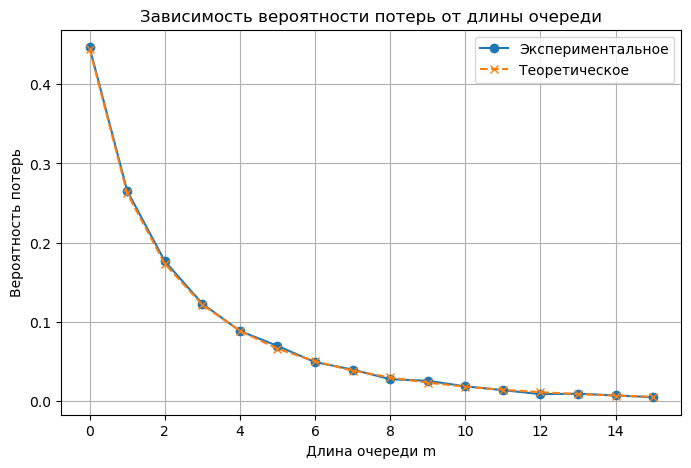

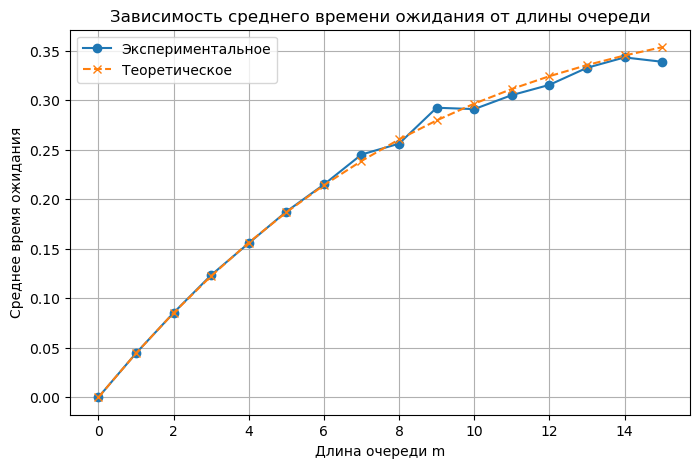

In [48]:
m_values = [res["m"] for res in results]
p_loss_values = [res["p_loss"] for res in results]
wq_values = [res["average_waiting_time"] for res in results]

theoretical = [formuls(lmbda, mu, m) for m in m_values]

p_loss_theoretical = [res["p_loss"] for res in theoretical]
wq_theoretical = [res["Wq"] for res in theoretical]

plt.figure(figsize=(8, 5))

plt.plot(m_values, p_loss_values, marker='o', label="Экспериментальное")

plt.plot(m_values, p_loss_theoretical,
         marker='x', linestyle='--', label="Теоретическое")

plt.xlabel("Длина очереди m")
plt.ylabel("Вероятность потерь")
plt.title("Зависимость вероятности потерь от длины очереди")
plt.grid(True)
plt.legend()

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(m_values, wq_values, marker='o', label="Экспериментальное")

plt.plot(m_values, wq_theoretical, marker='x', linestyle='--', label="Теоретическое")

plt.xlabel("Длина очереди m")
plt.ylabel("Среднее время ожидания")
plt.title("Зависимость среднего времени ожидания от длины очереди")
plt.grid(True)
plt.legend()

plt.show()

## Вывод

В ходе работы была исследована система массового обслуживания M/M/1/m с ограниченной очередью. 
Были рассмотрены как теоретические формулы, так и имитационная модель системы.

В результате установлено, что при увеличении длины очереди вероятность потерь уменьшается, так как система может принять больше заявок. 
Однако увеличение длины очереди приводит к росту среднего времени ожидания заявок.

Оптимальной считается минимальная длина очереди, при которой вероятность потерь не превышает 5%. 
Таким образом, выбор длины очереди является компромиссом между снижением потерь и временем ожидания.

Построены графики зависимости вероятности потерь и среднего времени ожидания от длины очереди.
Сравнение теоретических и имитационных результатов показало их близкое совпадение, что подтверждает корректность реализованной модели.